# 04 - Model Evaluation

This notebook estimates the predictive performance of multiple machine learning models on the processed dataset.

Several variants of logistic regression are included as baseline models, specifically LASSO (L1-regularized) and Ridge (L2-regularized) logistic regression. Decision tree models using the Gini impurity criterion are also evaluated, alongside XGBoost, which is commonly regarded as one of the strongest-performing methods for structured tabular data.

Model performance is estimated using 5-fold cross-validation to provide a robust assessment of generalization performance using the following metrics:

- Accuracy
- Precision (Positive Predictive Value)
- Recall (True Positive Rate)
- Specificity (True Negative Rate)
- Negative Predictive Value
- ROC-AUC
- F1 Score

## Imports

In [1]:
import sys

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics

from IPython.display import display, HTML

sys.path.append("../src")

from my_datasets import census
from my_datasets import dataframe_utils
import ml_utils
from ml_utils import evaluation
from ml_utils import model_pipelines
from ml_utils import visualizations

## Helper Functions

The following helper functions are used throughout this notebook to streamline performance evaluation and result visualization.

### `run_model_evaluation`

Reusable function for evaluating multiple machine learning models using cross-validation.

In [2]:
def run_model_evaluation(
    df,
    feature_columns,
    target_column,
    models,
    metrics,
    train_weight_column,
    eval_weight_column,
    return_folds=False,
    cv=5,
    results_filename=None
):
    train_sample_weight = (
        df[train_weight_column]
        / df[train_weight_column].mean()
    )

    eval_sample_weight = df[eval_weight_column]

    import warnings
    from sklearn.exceptions import ConvergenceWarning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", FutureWarning)

        performance_df = evaluation.get_model_performance(
            df,
            feature_columns=feature_columns,
            target_column=target_column,
            models=models,
            cv=cv,
            metrics=metrics,
            return_folds=return_folds,
            train_sample_weight=train_sample_weight,
            eval_sample_weight=eval_sample_weight,
        )

    def format_model_name(name):
        if name == "xgboost":
            return "XGBoost"
    
        return name.replace("_", " ").title().replace("Lasso", "LASSO")

    mapping = {
        model_name : format_model_name(model_name)
        for model_name in performance_df["model"].unique()
    }
    performance_df["model"] = performance_df["model"].map(mapping)

    if results_filename is not None:
        census.save_results_dataframe(
            performance_df, filename=results_filename
        )

    with pd.option_context("display.max_columns", None):
        display(
            evaluation.long_results_to_wides(performance_df)[mapping.values()]
        )

### `plot_grouped_results`

Generic helper function for generating grouped bar plots from evaluation results. The function splits the data by a specified top-level variable, then visualizes comparisons between a grouping variable and a labeling variable within each subset. This supports consistent comparison of model performance across different evaluation configurations.

In [3]:
def plot_grouped_results(df, top_level, group, label, value="mean", std="std", colors=None):
    for top_name, top_df in df.groupby(top_level):        
        _,fig,ax = visualizations.grouped_bar_plot(
            df=top_df,
            data_column=value,
            group_column=group,
            label_column=label,
            colors=colors,
            std_column=std,
            std_colors="black",
            title=str(top_name),
            xlabel=group.replace("_", " ").title(),
            ylabel="Mean 5-Fold CV Performance",
            std_errorbar_kwargs={"capsize":5},
            figsize=(2 * 6.4, 4.8),
            return_fig=True
        )
        ax.legend(
            title=label.replace("_", " ").title(),
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            ncol=1,
            frameon=True,
            columnspacing=0.8,
            handletextpad=0.4,
            borderaxespad=0
        )
        plt.show()

        filename = (
            f"{top_name}.png"
            .replace(" ", "_")
            .replace("-", "_")
            .lower()
        )
        census.save_figure(fig=fig, filename=filename)

## Feature Exclusion

Several features have previously been selected for exclusion from the models. This section defines those features.

In [4]:
exclude_features = [
    "hispanic origin",
    "detailed occupation recode",
    "detailed industry recode",

    "veterans benefits",
    "detailed household and family stat",

    "family members under 18",
    "region of previous residence",
    "state of previous residence",

    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",

    "year"
]

## Evaluation Metrics

Several metrics have been selected for evaluation across all experiments. These metrics capture different aspects of classification performance, including overall accuracy, class-wise performance, and ranking quality.

In [5]:
metrics = {
	"ROC-AUC": "roc_auc",
    "F1": sklearn.metrics.make_scorer(
        sklearn.metrics.f1_score,
        pos_label="50000+."
    ),
	"Precision": "precision_macro",
	"Recall": "recall_macro",
	"Specificity": "specificity",
	"Negative Predictive Value": "negative_predictive_value",
	"Accuracy": "accuracy",
}

## Data Loading and Inspection

The cleaned, processed dataset is loaded into a dataframe and basic inspection is performed to verify that it has been loaded correctly.

The target and sample weight columns are identified, along with the numeric-categorical features.

In [6]:
data_df = census.load_processed_dataframe("clean_data.csv", header=0, verbose=False)

dataframe_utils.print_dataframe_info(data_df)

target_column = census.get_target_feature()
weight_column = census.get_sample_weights_feature()

numeric_categorical_features = census.get_numeric_categorical_features()

# # subsample for code testing
# from sklearn.model_selection import train_test_split
# data_df, _ = train_test_split(
#     data_df,
#     train_size=1000,
#     stratify=data_df[target_column],
#     random_state=42,
# )
# data_df = data_df.reset_index(drop=True)
# dataframe_utils.print_dataframe_info(data_df)

DataFrame Memory Usage: 362.04 MB


,dtype,count,non_null,null_count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,int64,199523,199523,0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class of worker,str,199523,199523,0,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detailed industry recode,int64,199523,199523,0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
detailed occupation recode,int64,199523,199523,0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,str,199523,199523,0,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage per hour,int64,199523,199523,0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enroll in edu inst last wk,str,199523,199523,0,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital stat,str,199523,199523,0,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major industry code,str,199523,199523,0,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major occupation code,str,199523,199523,0,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Not in labor force,0,0,0,Joint both 65+,Not in universe,Not in universe,Householder,Householder,955.27,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11t

## Feature Type Separation and Adjustments

The dataset features are split into categorical and numeric column groups, with additional numeric-categorical features explicitly treated as categorical.

Adjustments are made to ensure correct feature assignment and prevent data leakage. The target column is removed from the categorical feature list, while the sample weight column is removed from the numeric feature list. In addition, all preselected excluded features are removed from consideration.

In [7]:
categorical_columns, numeric_columns = ml_utils.get_categorical_numeric_split(
    data_df,
    treat_as_categorical=numeric_categorical_features
)

exclude_set = set(exclude_features)
exclude_set.update([target_column, weight_column])

categorical_columns = [
    column
    for column in categorical_columns
    if column not in exclude_set
]

numeric_columns = [
    column
    for column in numeric_columns
    if column not in exclude_set
]

## Target Variable Distribution and Weighting Strategies

The weighted and unweighted target distributions are nearly identical. This indicates that sample weights have limited impact on the overall class balance. However, sample weights remain important for preserving representativeness of the underlying population.

To address potential performance issues caused by class imbalance, three different weighting strategies are evaluated during training:

- **Original sample weights** are used for training without modification, preserving the original population structure.

- **Class-balanced weights (preserving within-class structure)** rescale sample weights so that each target class contributes equally to the training objective, while preserving relative differences between samples within each class.

- **Fully uniform class weights** rescale sample weights so that each target class contributes equally to the training objective, with all samples within a class given equal weight.

These adjustments are used only during model training. The original sample weights are retained for evaluation to ensure results remain representative of the underlying data distribution.

In [8]:
class_balanced_weight_column = "class_balanced_weights"
class_weight_totals = (
	data_df.groupby(target_column)[weight_column]
	.sum()
)
data_df[class_balanced_weight_column] = (
	data_df[weight_column]
	* data_df[target_column].map(
		class_weight_totals.sum()
		/ len(class_weight_totals)
		/ class_weight_totals
	)
)

fully_uniform_class_weight_column = "uniform_class_balanced_weights"
class_counts = (
	data_df[target_column]
	.value_counts()
)
data_df[fully_uniform_class_weight_column] = (
	data_df[target_column].map(
		len(data_df)
		/ data_df[target_column].nunique()
		/ class_counts
	)
)

class_distribution_df = pd.concat(
	{
		"unweighted": data_df[target_column].value_counts(normalize=True).sort_index() * 100,
		"weighted": data_df.groupby(target_column)[weight_column].sum().pipe(lambda s: s / s.sum() * 100),
		"class balanced": data_df.groupby(target_column)[class_balanced_weight_column].sum().pipe(lambda s: s / s.sum() * 100),
		"uniform class balanced": data_df.groupby(target_column)[fully_uniform_class_weight_column].sum().pipe(lambda s: s / s.sum() * 100),
	},
	axis=1
)

display(HTML("<h3>Class Distribution Comparison</h3>"))
display(class_distribution_df)

,unweighted,weighted,class balanced,uniform class balanced
label,,,,
- 50000.,93.794199,93.594958,50.0,50.0
50000+.,6.205801,6.405042,50.0,50.0


## Model Pipelines

The model pipelines are loaded and displayed for inspection to ensure they are correctly configured.

In [9]:
models = model_pipelines.get_prediction_models(
	categorical_columns=categorical_columns,
	numeric_columns=numeric_columns,
)

for name,model in models.items():
    display(HTML(f"<h3>{name}</h3>"))
    display(model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('LogisticRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('LogisticRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('DecisionTreeClassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('XGBStringClassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

## Performance Evaluation of Baseline Models

This section presents model training and evaluation under different weighting schemes. Each subsection trains the same set of baseline models using consistent cross-validation procedures, evaluates their performance, and saves the results for later comparison.

### Evaluation with Original Sample Weights

Models are trained and evaluated using the original sample weights without any modification. This reflects performance under the observed weighted distribution and aligns with how the dataset represents the underlying population through its sampling design.

In [10]:
performance_df = run_model_evaluation(
	df=data_df,
	feature_columns=categorical_columns + numeric_columns,
	target_column=target_column,
	models=models,
	metrics=metrics,
	train_weight_column=weight_column,
	eval_weight_column=weight_column,
	cv=5,
    results_filename="original_sample_weights.csv"
)

lasso_logistic_regression
  0:00:55.457037
  0:00:55.743436
  0:00:55.302216
  0:00:56.360258
  0:00:55.429361
ridge_logistic_regression
  0:00:10.440393
  0:00:10.489854
  0:00:10.853262
  0:00:12.044209
  0:00:11.242288
decision_tree
  0:00:18.945639
  0:00:19.997772
  0:00:17.644690
  0:00:17.529315
  0:00:18.661681
xgboost
  0:00:13.227002
  0:00:13.676060
  0:00:13.997368
  0:00:12.884896
  0:00:12.658769


2026-06-17 18:08:36,374 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/original_sample_weights.csv


model                           LASSO Logistic Regression  \
metric                    stat                              
ROC-AUC                   max                    0.945815   
                          mean                   0.942826   
                          min                    0.940091   
                          std                    0.002199   
F1                        max                    0.509416   
                          mean                   0.499810   
                          min                    0.486550   
                          std                    0.008509   
Precision                 max                    0.846688   
                          mean                   0.837935   
                          min                    0.830309   
                          std                    0.005342   
Recall                    max                    0.692561   
                          mean                   0.686674   
                          min                    0.680852   
                          std                    0.004064   
Specificity               max                    0.990269   
                          mean                   0.989627   
                          min                    0.989317   
                          std                    0.000339   
Negative Predictive Value max                    0.960809   
                          mean                   0.959124   
                          min                    0.958183   
                          std                    0.000886   
Accuracy                  max                    0.952294   
                          mean                   0.950816   
                          min                    0.949733   
                          std                    0.000862   

model                           Ridge Logistic Regression  Decision Tree  \
metric                    stat                                             
ROC-AUC                   max                    0.945595       0.719376   
                          mean                   0.942753       0.716268   
                          min                    0.940044       0.710179   
                          std                    0.002150       0.003459   
F1                        max                    0.511677       0.476058   
                          mean                   0.501488       0.464597   
                          min                    0.490002       0.460185   
                          std                    0.008557       0.005843   
Precision                 max                    0.847254       0.720588   
                          mean                   0.836785       0.711686   
                          min                    0.830416       0.705234   
                          std                    0.005834       0.005098   
Recall                    max                    0.694296       0.719191   
                          mean                   0.687928       0.715998   
                          min                    0.682828       0.710466   
                          std                    0.004132       0.003223   
Specificity               max                    0.990256       0.963944   
                          mean                   0.989424       0.962199   
                          min                    0.989061       0.960357   
                          std                    0.000430       0.001294   
Negative Predictive Value max                    0.961032       0.964910   
                          mean                   0.959288       0.963658   
                          min                    0.958251       0.962605   
                          std                    0.000930       0.000854   
Accuracy                  max                    0.952277       0.932132   
                          mean                   0.950799       0.930656   
                          min            

### Evaluation with Class-Balanced Weights (Preserving Within-Class Structure)

Models are trained using class-balanced sample weights, while evaluation is performed using the original sample weights. This isolates the effect of rebalancing class contributions during training while keeping evaluation consistent with the underlying data distribution.

In [11]:
performance_df = run_model_evaluation(
	df=data_df,
	feature_columns=categorical_columns + numeric_columns,
	target_column=target_column,
	models=models,
	metrics=metrics,
	train_weight_column=class_balanced_weight_column,
	eval_weight_column=weight_column,
	cv=5,
    results_filename="class_balanced_weights.csv"
)

lasso_logistic_regression
  0:00:57.598613
  0:01:03.650377
  0:00:58.482854
  0:01:02.513990
  0:01:00.547148
ridge_logistic_regression
  0:00:09.846828
  0:00:10.008104
  0:00:09.825876
  0:00:10.037466
  0:00:09.983221
decision_tree
  0:00:17.255348
  0:00:18.103345
  0:00:16.459670
  0:00:17.980520
  0:00:19.031217
xgboost
  0:00:09.805122
  0:00:09.797427
  0:00:09.775611
  0:00:09.800693
  0:00:09.945296


2026-06-17 18:19:15,390 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/class_balanced_weights.csv


model                           LASSO Logistic Regression  \
metric                    stat                              
ROC-AUC                   max                    0.946690   
                          mean                   0.943607   
                          min                    0.941012   
                          std                    0.002202   
F1                        max                    0.447578   
                          mean                   0.438377   
                          min                    0.431710   
                          std                    0.005577   
Precision                 max                    0.644817   
                          mean                   0.640978   
                          min                    0.638112   
                          std                    0.002377   
Recall                    max                    0.877876   
                          mean                   0.872174   
                          min                    0.868267   
                          std                    0.003794   
Specificity               max                    0.853123   
                          mean                   0.850562   
                          min                    0.848558   
                          std                    0.001610   
Negative Predictive Value max                    0.992288   
                          mean                   0.991525   
                          min                    0.990659   
                          std                    0.000678   
Accuracy                  max                    0.855078   
                          mean                   0.853327   
                          min                    0.851377   
                          std                    0.001447   

model                           Ridge Logistic Regression  Decision Tree  \
metric                    stat                                             
ROC-AUC                   max                    0.946511       0.711840   
                          mean                   0.943465       0.707281   
                          min                    0.941026       0.704371   
                          std                    0.002102       0.002563   
F1                        max                    0.447051       0.451800   
                          mean                   0.438810       0.445670   
                          min                    0.432571       0.438762   
                          std                    0.005183       0.004960   
Precision                 max                    0.644599       0.705527   
                          mean                   0.641170       0.700226   
                          min                    0.638481       0.693104   
                          std                    0.002217       0.004168   
Recall                    max                    0.877299       0.711646   
                          mean                   0.872301       0.706967   
                          min                    0.868624       0.703923   
                          std                    0.003567       0.002640   
Specificity               max                    0.853696       0.961612   
                          mean                   0.850845       0.960126   
                          min                    0.848961       0.958093   
                          std                    0.001646       0.001216   
Negative Predictive Value max                    0.992316       0.963980   
                          mean                   0.991525       0.962524   
                          min                    0.990677       0.961593   
                          std                    0.000666       0.000895   
Accuracy                  max                    0.855623       0.929767   
                          mean                   0.853590       0.927691   
                          min            

### Evaluation with Fully Uniform Class Weights

Models are trained using fully uniform class weights, while evaluation is performed using the original sample weights. This approach ensures each target class contributes equally during training, with all samples within a class assigned identical weight. Evaluation remains based on the original sample-weighted distribution.

In [12]:
performance_df = run_model_evaluation(
	df=data_df,
	feature_columns=categorical_columns + numeric_columns,
	target_column=target_column,
	models=models,
	metrics=metrics,
	train_weight_column=fully_uniform_class_weight_column,
	eval_weight_column=weight_column,
	cv=5,
    results_filename="fully_uniform_class_weights.csv"
)

lasso_logistic_regression
  0:00:58.906271
  0:00:58.758566
  0:01:00.971274
  0:00:59.311058
  0:01:00.443152
ridge_logistic_regression
  0:00:09.994633
  0:00:09.979639
  0:00:10.279972
  0:00:09.950175
  0:00:10.035575
decision_tree
  0:00:17.379049
  0:00:18.118051
  0:00:17.274004
  0:00:16.768312
  0:00:17.267204
xgboost
  0:00:09.801160
  0:00:09.866968
  0:00:09.728534
  0:00:09.781635
  0:00:09.860871


2026-06-17 18:29:45,063 - INFO - Saved DataFrame to results directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/results/fully_uniform_class_weights.csv


model                           LASSO Logistic Regression  \
metric                    stat                              
ROC-AUC                   max                    0.946818   
                          mean                   0.943830   
                          min                    0.941328   
                          std                    0.002150   
F1                        max                    0.442187   
                          mean                   0.435670   
                          min                    0.429385   
                          std                    0.004618   
Precision                 max                    0.642414   
                          mean                   0.639748   
                          min                    0.637034   
                          std                    0.001975   
Recall                    max                    0.876652   
                          mean                   0.872360   
                          min                    0.867673   
                          std                    0.003390   
Specificity               max                    0.851881   
                          mean                   0.848143   
                          min                    0.845753   
                          std                    0.002017   
Negative Predictive Value max                    0.992467   
                          mean                   0.991722   
                          min                    0.990650   
                          std                    0.000688   
Accuracy                  max                    0.853920   
                          mean                   0.851242   
                          min                    0.849080   
                          std                    0.001570   

model                           Ridge Logistic Regression  Decision Tree  \
metric                    stat                                             
ROC-AUC                   max                    0.946557       0.717413   
                          mean                   0.943679       0.709792   
                          min                    0.941393       0.703467   
                          std                    0.002006       0.005445   
F1                        max                    0.442846       0.465166   
                          mean                   0.436346       0.449496   
                          min                    0.429275       0.437860   
                          std                    0.004705       0.009709   
Precision                 max                    0.642707       0.710461   
                          mean                   0.640045       0.701840   
                          min                    0.636991       0.691471   
                          std                    0.002010       0.006122   
Recall                    max                    0.876790       0.716994   
                          mean                   0.872541       0.709429   
                          min                    0.868029       0.703113   
                          std                    0.003281       0.005404   
Specificity               max                    0.852059       0.961360   
                          mean                   0.848601       0.960167   
                          min                    0.845765       0.957324   
                          std                    0.002013       0.001462   
Negative Predictive Value max                    0.992400       0.964356   
                          mean                   0.991719       0.962850   
                          min                    0.990695       0.961686   
                          std                    0.000649       0.001014   
Accuracy                  max                    0.854120       0.929960   
                          mean                   0.851664       0.928044   
                          min            

## Visualizations

This section presents visual summaries of the evaluation results, enabling comparison of model performance across weighting schemes and metrics.

### Reload Results

This step reloads the saved results and combines them into a single DataFrame for visualization.

In [13]:
result_filenames = [
    "class_balanced_weights.csv",
    "fully_uniform_class_weights.csv",
    "original_sample_weights.csv"
]

def load_result_data(filename):
    weight_scheme = filename.split(".")[0].replace("_", " ").title().replace("Class Balanced", "Class-Balanced")
    df = census.load_results_dataframe(filename, header=0, verbose=False)
    df["weight_scheme"] = weight_scheme
    return df

results_df = pd.concat(
    [load_result_data(filename) for filename in result_filenames],
    axis=0,
    ignore_index=True
)

display(results_df)

,model,metric,mean,std,min,max,weight_scheme
0,LASSO Logistic Regression,ROC-AUC,0.943607,0.002202,0.941012,0.946690,Class-Balanced Weights
1,LASSO Logistic Regression,F1,0.438377,0.005577,0.431710,0.447578,Class-Balanced Weights
2,LASSO Logistic Regression,Precision,0.640978,0.002377,0.638112,0.644817,Class-Balanced Weights
3,LASSO Logistic Regression,Recall,0.872174,0.003794,0.868267,0.877876,Class-Balanced Weights
4,LASSO Logistic Regression,Specificity,0.850562,0.001610,0.848558,0.853123,Class-Balanced Weights
...,...,...,...,...,...,...,...
79,XGBoost,Precision,0.858661,0.007563,0.843859,0.864199,Original Sample Weights
80,XGBoost,Recall,0.711782,0.007051,0.699391,0.719726,Original Sample Weights
81,XGBoost,Specificity,0.990390,0.000488,0.989604,0.991004,Original Sample Weights
82,XGBoost,Negative Predictive Value,0.962312,0.001005,0.961279,0.964177,Original Sample Weights


### Model Selection Across Weighting Schemes

This section addresses the primary selection question: which model performs best under different weighting schemes.

The results compare models across evaluation metrics within each weighting scheme, allowing direct ranking of models under consistent training conditions.

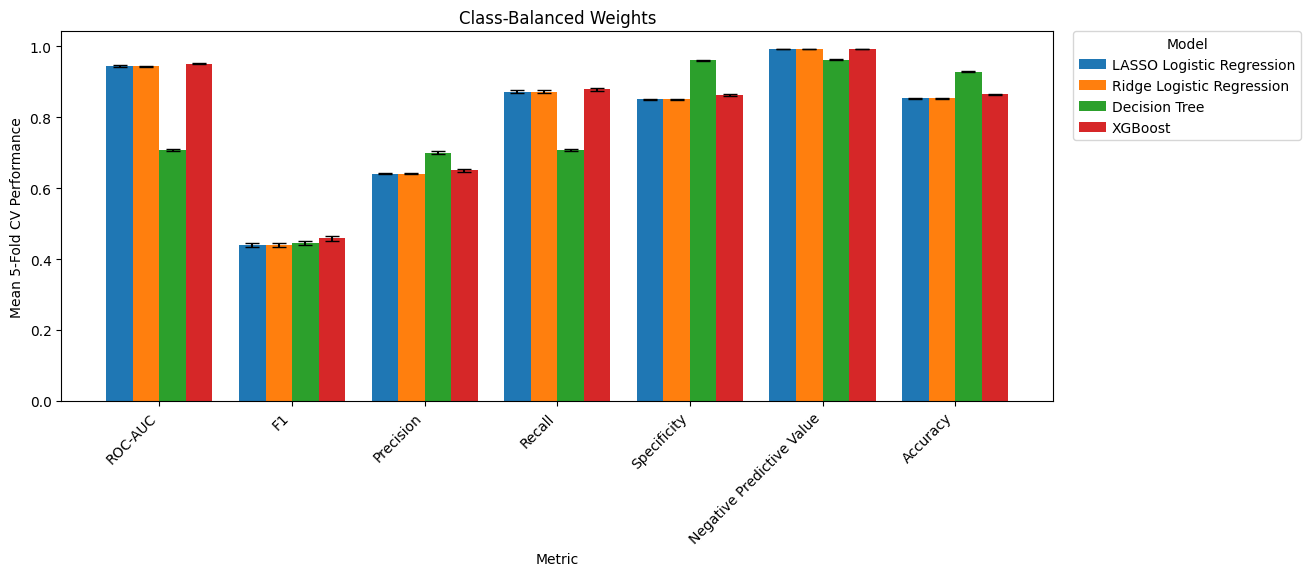

2026-06-17 18:29:45,757 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/class_balanced_weights.png


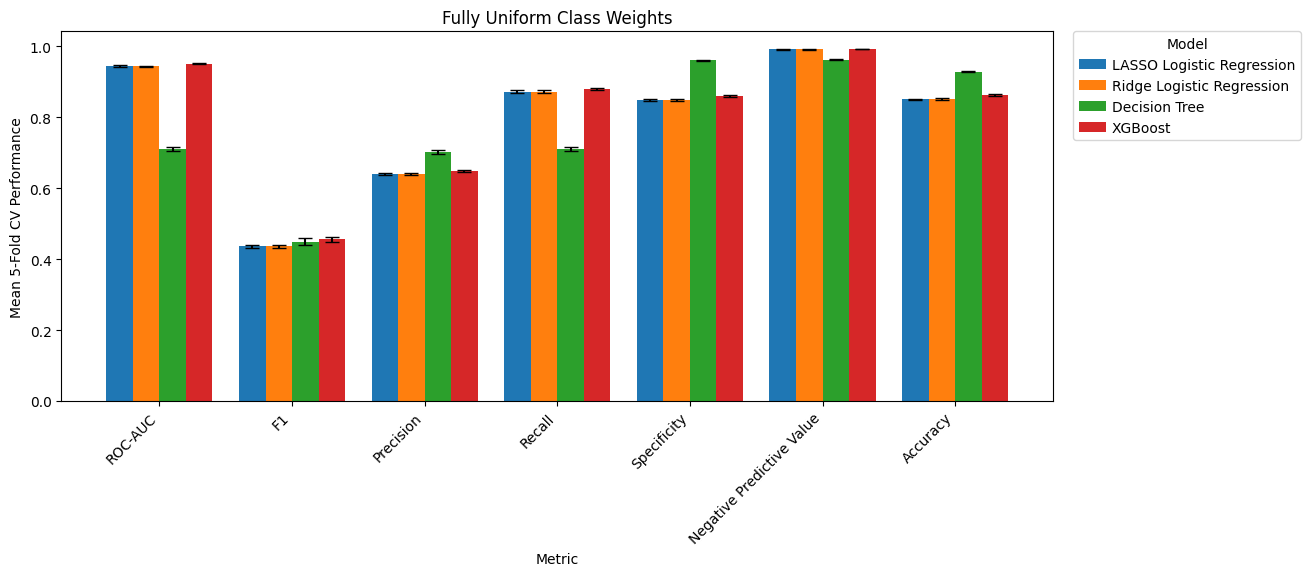

2026-06-17 18:29:46,126 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/fully_uniform_class_weights.png


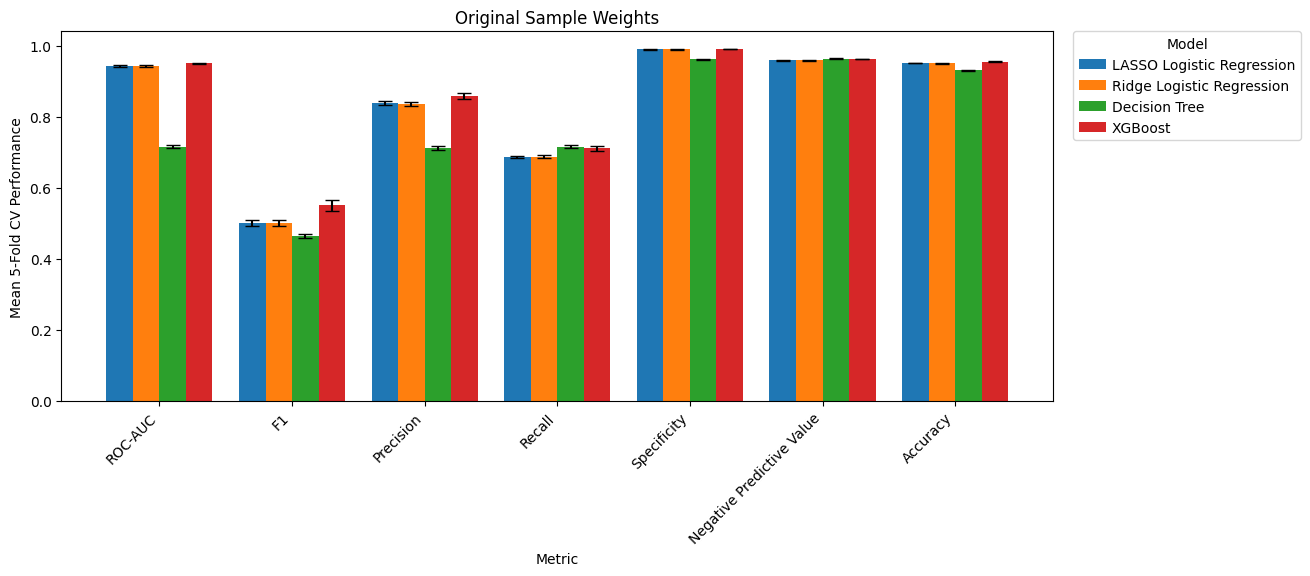

2026-06-17 18:29:46,483 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/original_sample_weights.png


In [14]:
plot_grouped_results(
    results_df,
    top_level="weight_scheme",
    group="metric",
    label="model",
    colors=plt.get_cmap("tab10").colors
)

### Weighting Scheme Sensitivity by Model

This section evaluates how sensitive each model is to changes in the training weighting strategy.

The results compare weighting schemes across evaluation metrics within each model, highlighting whether performance is stable or dependent on the chosen weighting configuration.

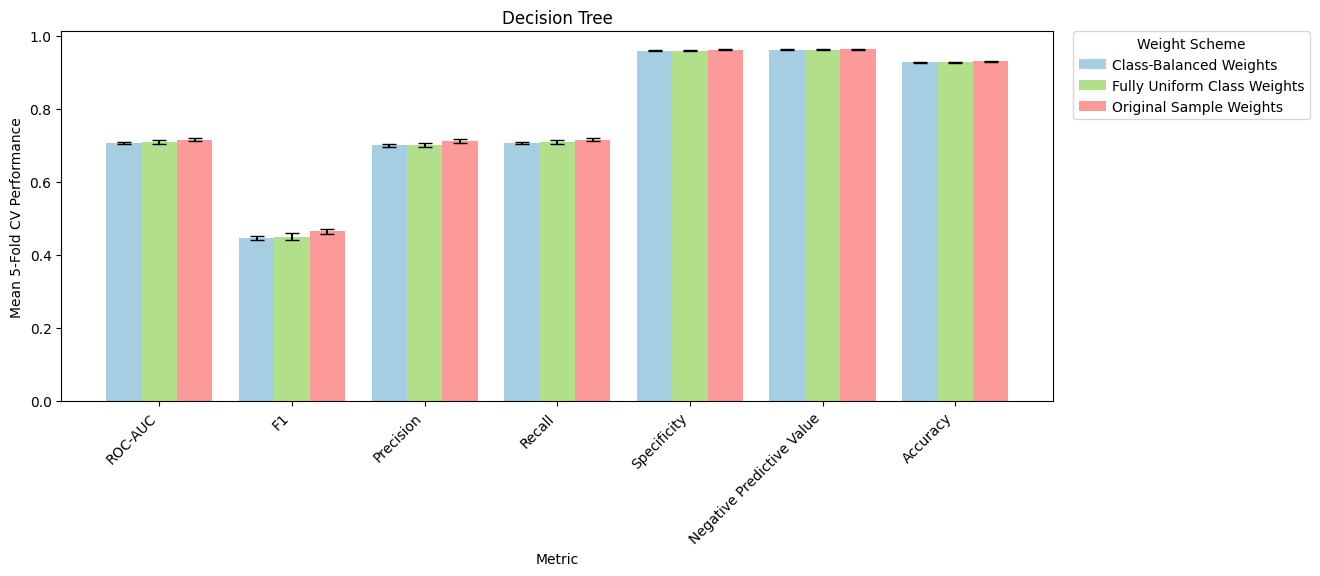

2026-06-17 18:29:46,808 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/decision_tree.png


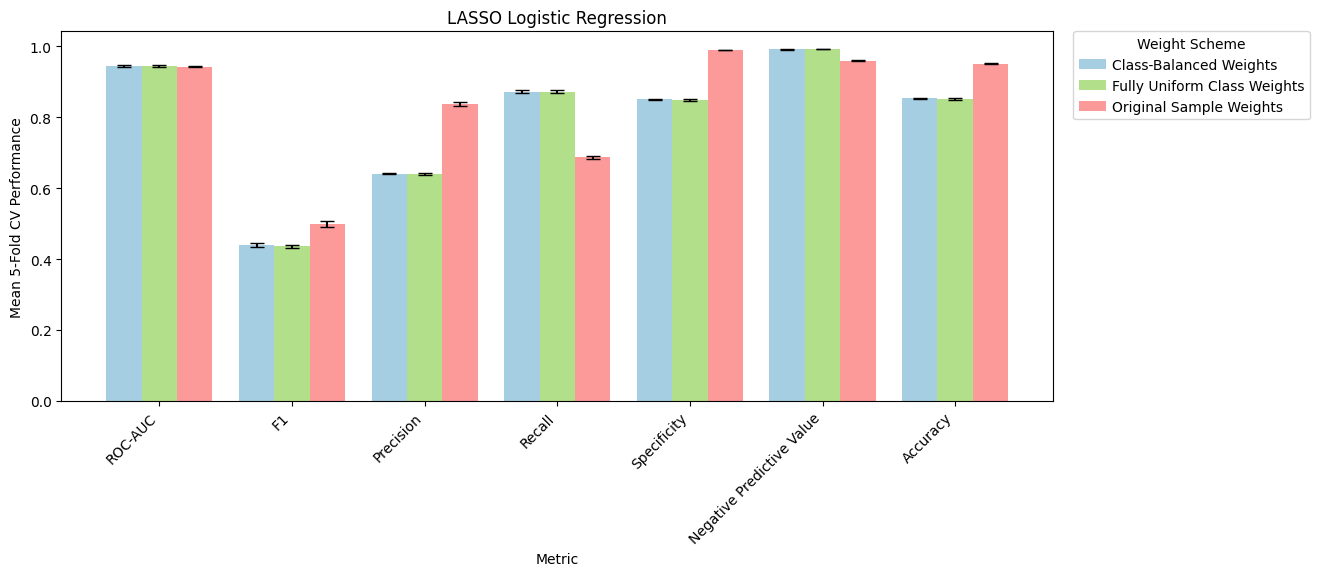

2026-06-17 18:29:47,121 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/lasso_logistic_regression.png


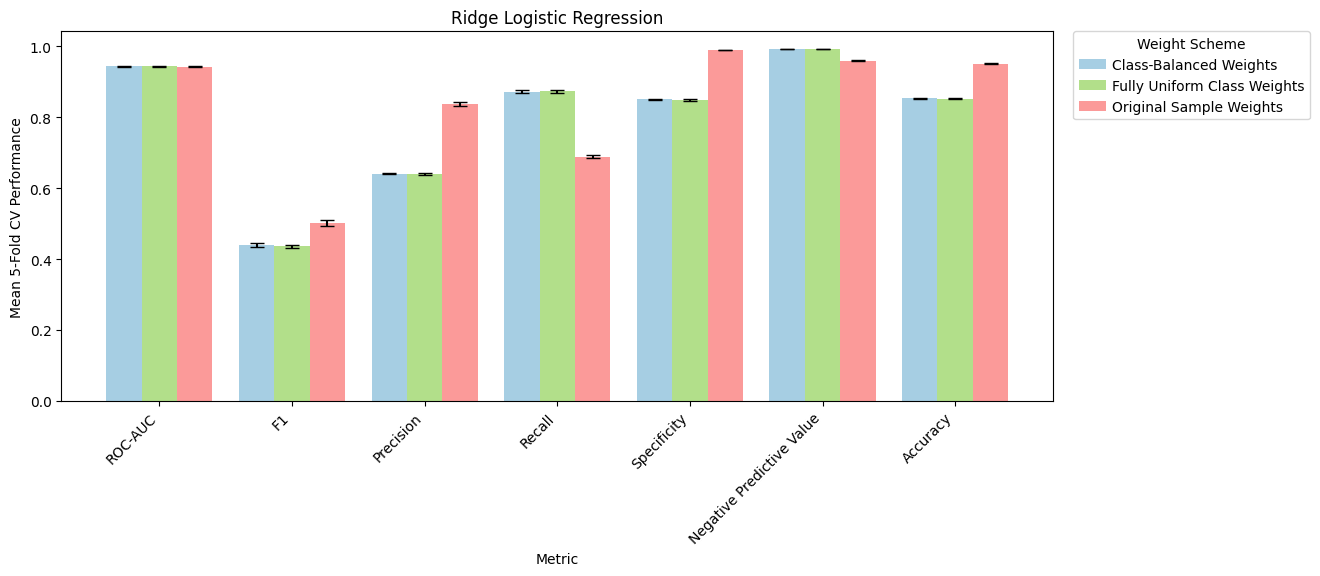

2026-06-17 18:29:47,446 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/ridge_logistic_regression.png


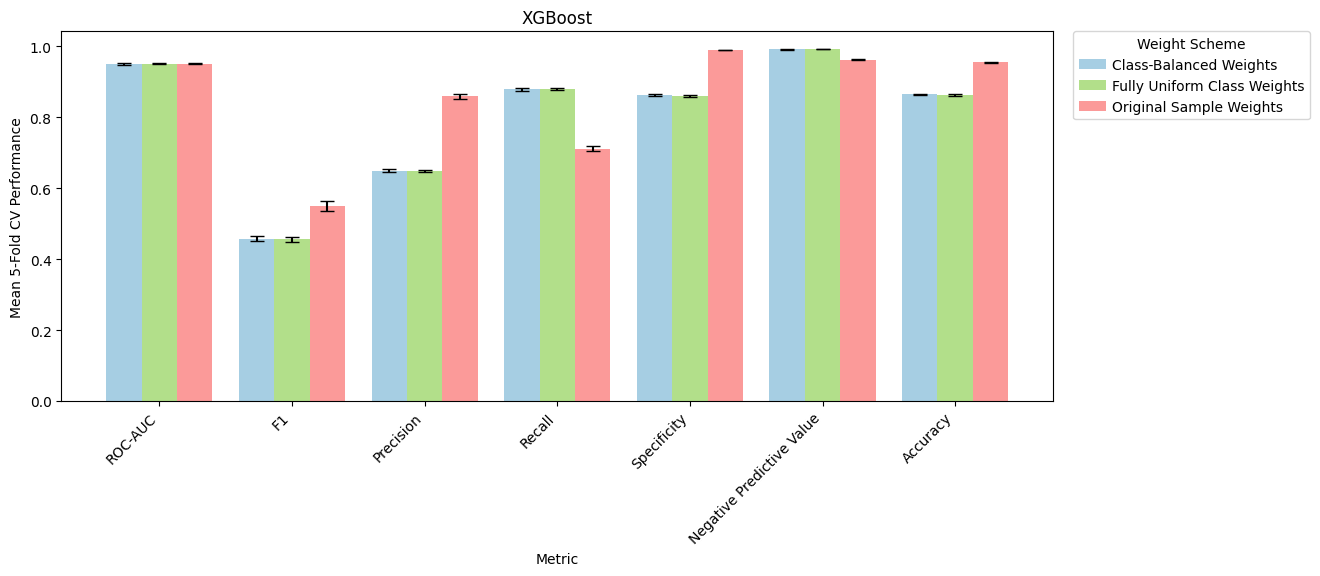

2026-06-17 18:29:47,766 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/xgboost.png


In [15]:
plot_grouped_results(
    results_df,
    top_level="model",
    group="metric",
    label="weight_scheme",
    colors=plt.get_cmap("Paired").colors[::2]
)

### Metric Agreement Across Models and Weighting Schemes

This section examines whether evaluation metrics lead to consistent conclusions about model performance.

The results compare models across weighting schemes within each metric, revealing whether model rankings are stable or metric-dependent.

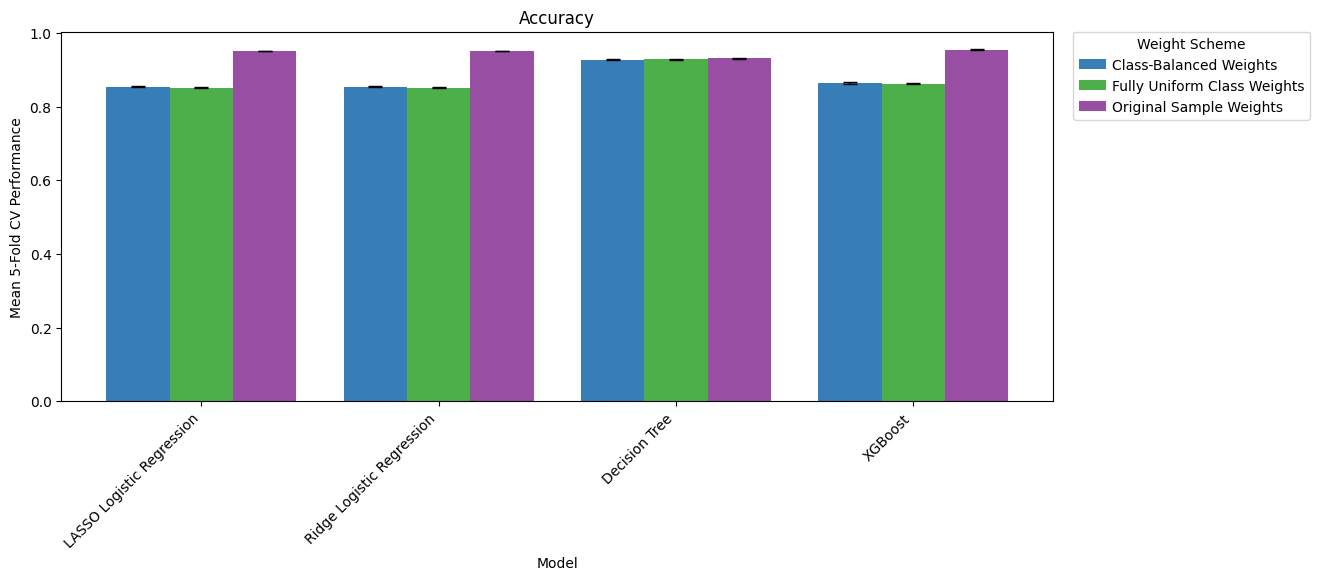

2026-06-17 18:29:48,041 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/accuracy.png


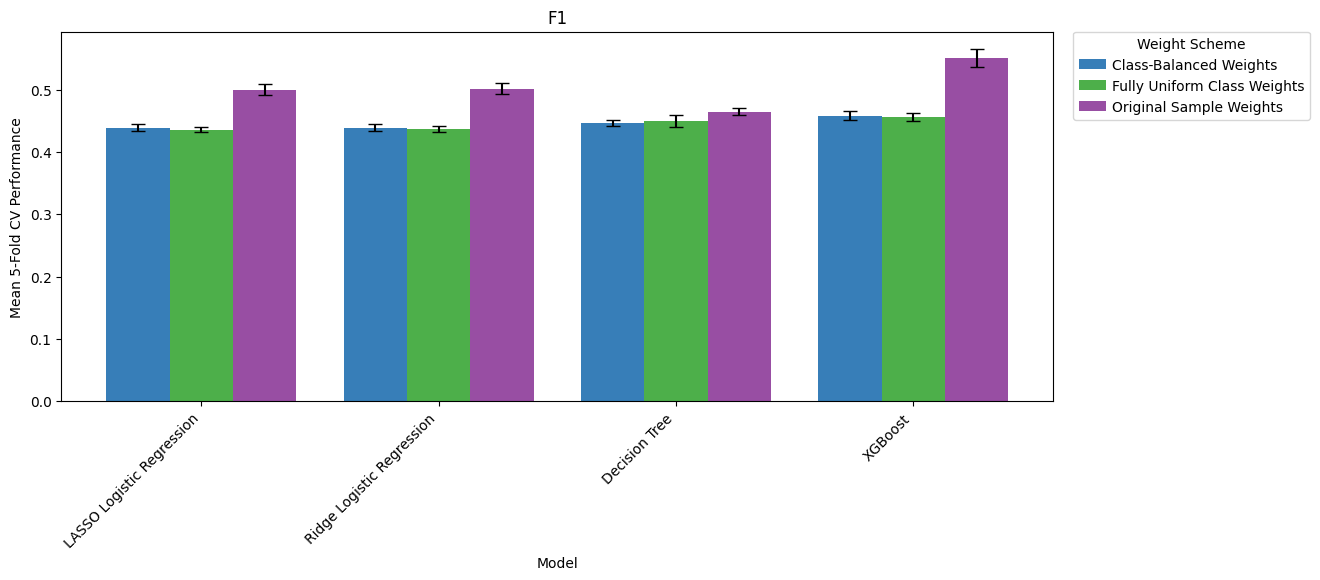

2026-06-17 18:29:48,304 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/f1.png


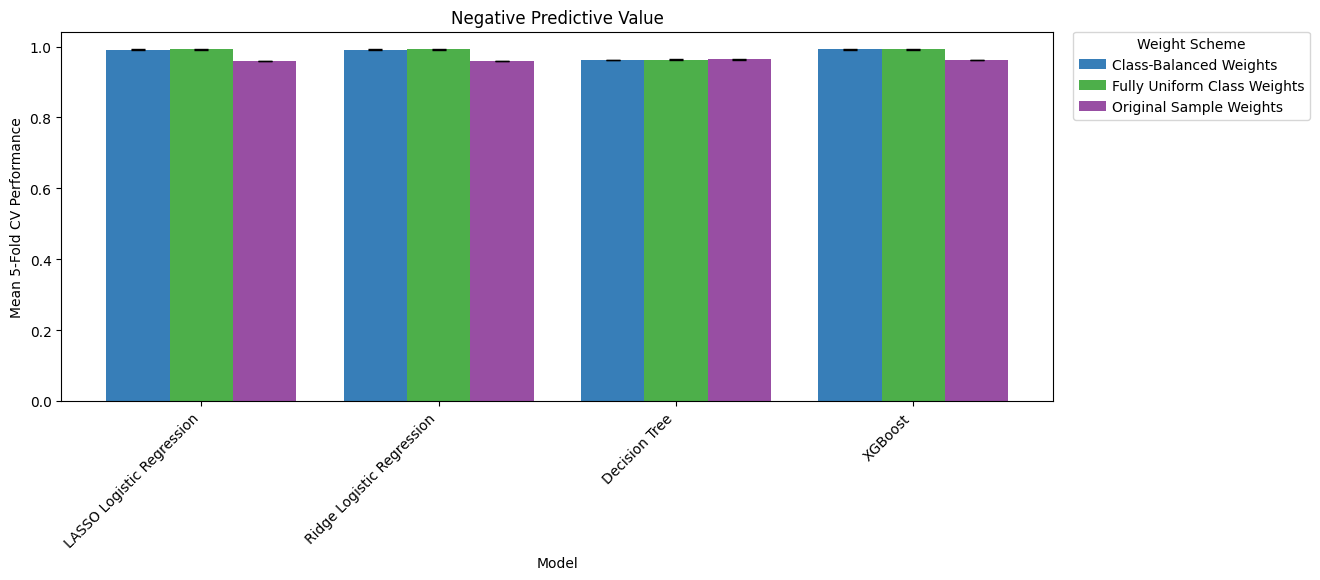

2026-06-17 18:29:48,565 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/negative_predictive_value.png


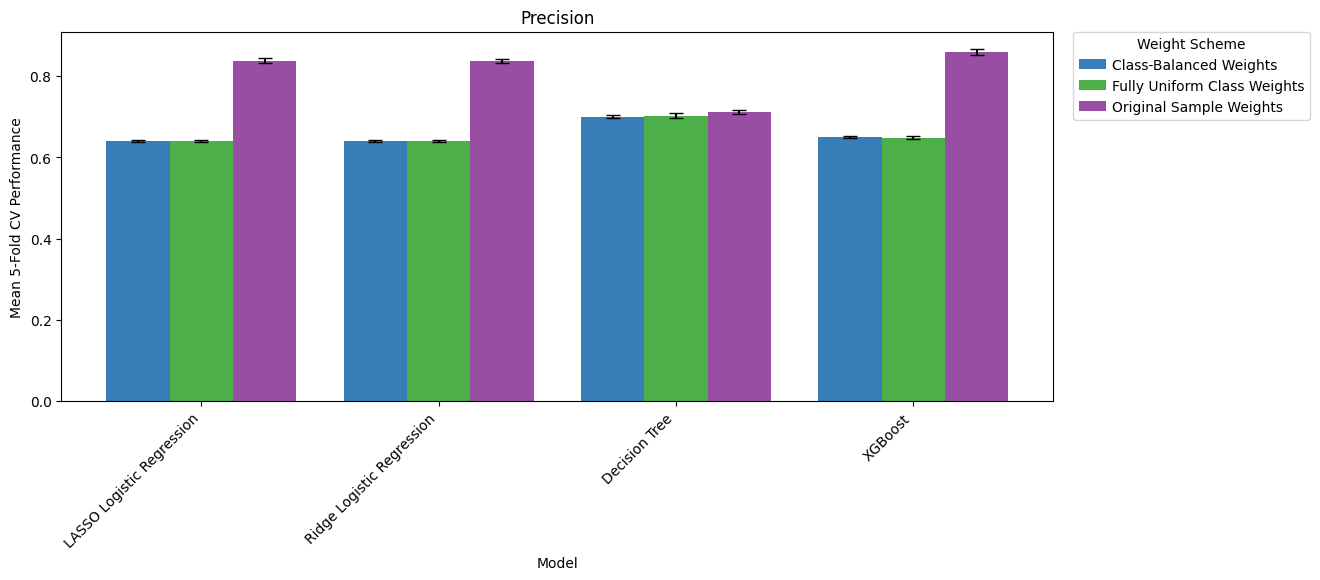

2026-06-17 18:29:48,818 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/precision.png


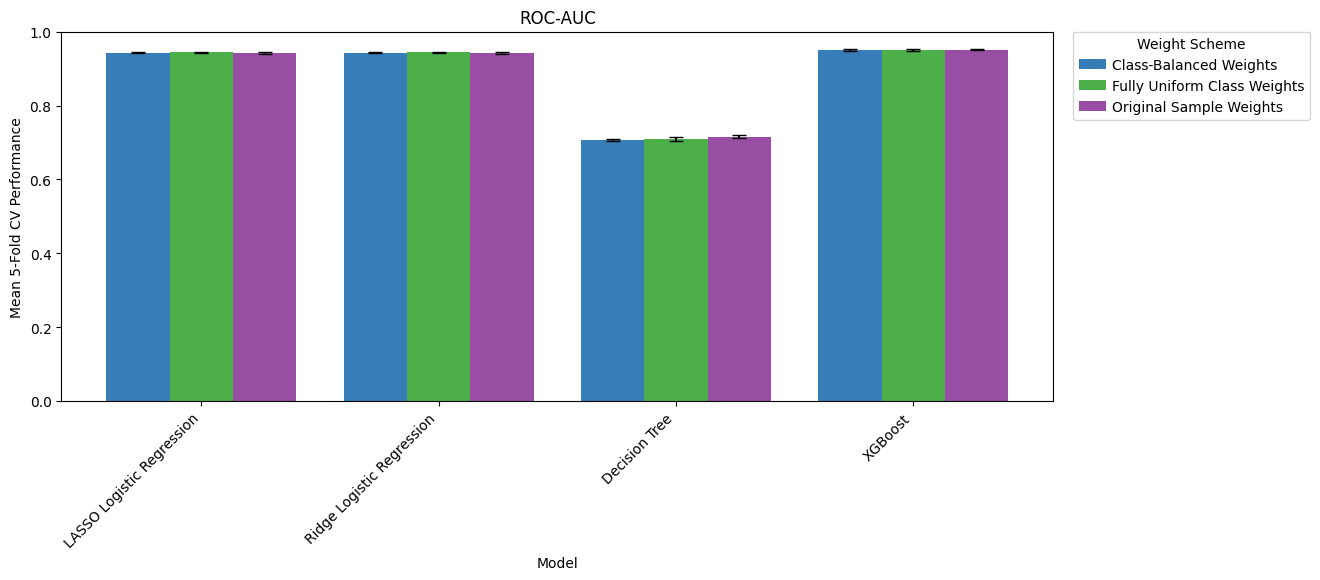

2026-06-17 18:29:49,081 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/roc_auc.png


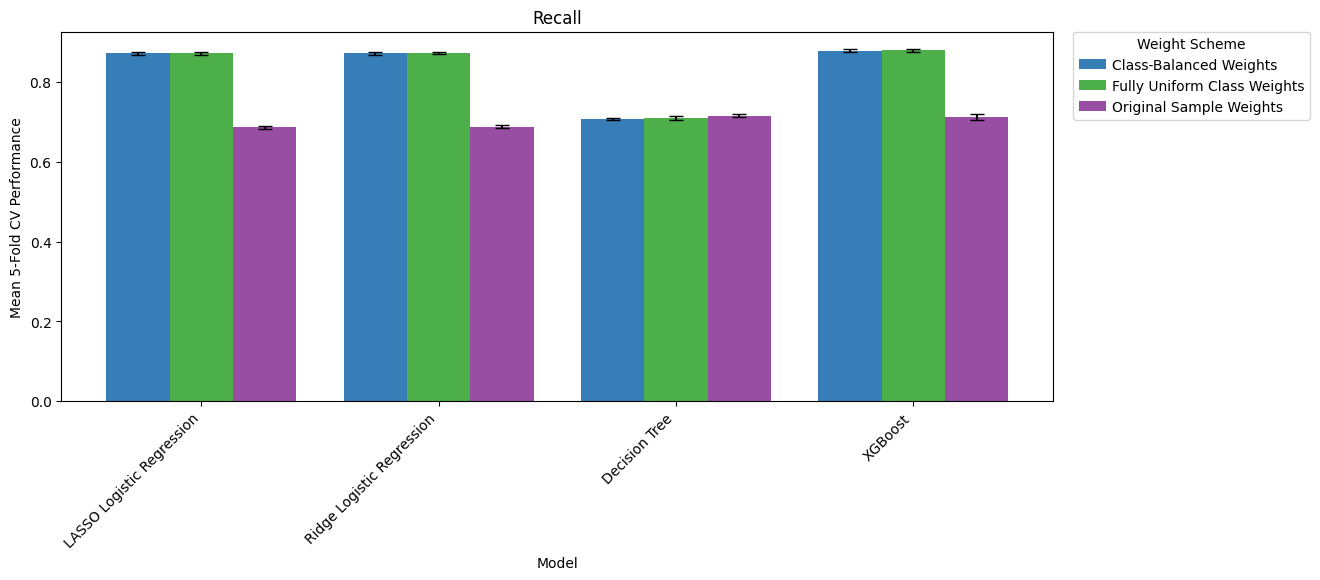

2026-06-17 18:29:49,335 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/recall.png


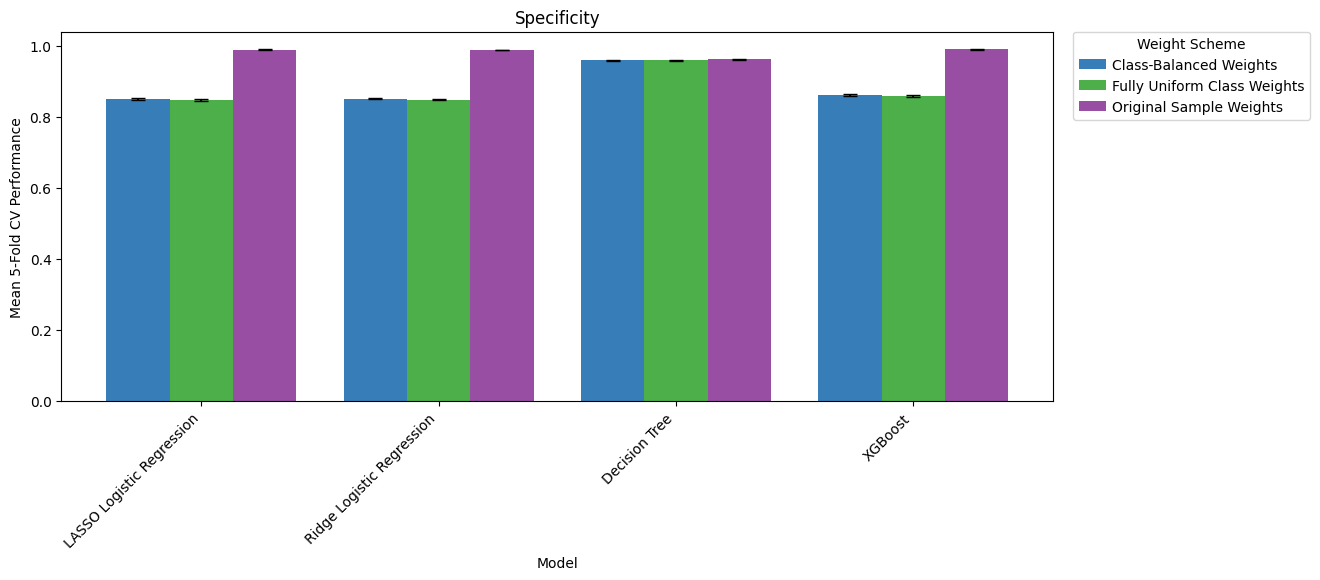

2026-06-17 18:29:49,596 - INFO - Saved figure to figures directory: /Users/jagraves21/notebooks/jpm/census-income-ml-project/data/Census/figures/specificity.png


In [16]:
plot_grouped_results(
    results_df,
    top_level="metric",
    group="model",
    label="weight_scheme",
    colors=plt.get_cmap("Set1").colors[1:]
)